[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> Epsilon-Greedy con Decaimiento](https://colab.research.google.com/github/AlbertoLopezCorbalan/eml-albertolopezc/blob/main/k_brazos/epsilon-greedy-decay.ipynb) 

# Estudio comparativo de algoritmos en un problema de k-armed bandit

El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Alberto López Corbalán
    Email: alberto.lopezc@um.es
    Date: 2026/06/05



## Configuración del entorno

Si el notebook se está ejecutando en Google Colab, clona el repositorio del proyecto. Además, añade la carpeta `src` al `PYTHONPATH` para permitir la importación de módulos propios.

In [1]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone https://github.com/AlbertoLopezCorbalan/eml-albertolopezc
    %cd eml-albertolopezc/k_brazos

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


## Importación de dependencias
Se importan las librerías y módulos necesarios para la simulación de problemas de bandits multi-brazo.

In [2]:
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedyDecay
from arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.


**Entrada:** Bandido (B), conjunto de algoritmos (A), número de pasos (S), número de ejecuciones (R)

**Salida:** Recompensas medias, porcentaje de selecciones óptimas, regret acumulado y estadísticas por brazo.

- Inicializar las estructuras para almacenar las métricas.
- Para cada ejecución $r \in \{1,\dots,R\}$:
   - Crear una nueva instancia de (B).
   - Reiniciar todos los algoritmos de (A).
   - Para cada paso $s \in \{1,\dots,S\}$
       - Para cada algoritmo $ a \in A$:
            - Seleccionar un brazo $b_s$.
            - Obtener la recompensa $r_s$ al accionar $b_s$.
            - Actualizar las estimaciones de $a$ con $r_s$.
            - Registrar la recompensa obtenida.
            - Actualizar las estadísticas del brazo seleccionado.
            - Calcular las métricas

**Nota:** Cada ejecución consta de $S$ pasos consecutivos de interacción con el bandido $B$. El experimento se repite $R$ veces y las métricas finales se obtienen promediando los resultados de todas las ejecuciones.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps))  # Matriz para almacenar el rechazo acumulado

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    # Información para la función plot_arm_statistics
    arm_selections = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar los brazos elegidos
    arm_rewards_sum = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar las recompensas de cada brazos

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)
        # Obtener la recompensa esperada óptima
        q_max = current_bandit.get_expected_value(current_bandit.optimal_arm)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        regret_accumulated_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.

                arm_selections[idx, chosen_arm] += 1 # Acumular el numero de selecciones de un brazo
                arm_rewards_sum[idx, chosen_arm] += reward # Acumular las recompensas de ese brazo

                regret_accumulated_per_algo[idx] += q_max - current_bandit.get_expected_value(chosen_arm) # Se calcula la perdida
                regret_accumulated[idx, step] += regret_accumulated_per_algo[idx]  # Acumulamos la perdida por no elegir el brazo correcto
                
                if optimal_arm == chosen_arm:
                    optimal_selections[idx, step] += 1 # Si el brazo elegido se corresponda con el brazo óptimo

                algo.decay_exploration() # Para implementar el epsilon-decay

    
    rewards /= runs
    regret_accumulated /= runs
    optimal_selections = (optimal_selections / runs) * 100 # Calcula el porcentaje de selecciones óptimas

    # Calculamos el promedio de las ganancias de cada brazo
    avg_arm_rewards = np.divide(arm_rewards_sum, arm_selections, out=np.zeros_like(arm_rewards_sum), where=arm_selections > 0)

    return rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections

## Configuración del experimento

La selección del brazo para este notebook se fundamenta en el método $\epsilon$-greedy-decay:
- Generar un valor aleatorio $u \sim U(0,1)$.
   - Si $u < \epsilon$:
     - **Exploración:** seleccionar un brazo aleatorio.
   - En caso contrario:
     - **Explotación:** seleccionar el brazo que maximiza la recompensa media estimada

       $$
       a_t = \arg\max_a Q_t(a)
       $$

**Nota:** En este estudio el parámetro de exploración ($\epsilon$) no es constante, sino que decrece con el tiempo, de forma que el algoritmo explora más en las primeras etapas y progresivamente se vuelve más explotador a medida que aumenta la confianza en las estimaciones. Además, presentan un primer barrido por todos los brazos para una estimación inicial.

Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy decay para valores (iniciales) epsilon: 1.0, 0.5, y 0.25.

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy-decay con diferentes valores de epsilon iniciales.
algorithms = [EpsilonGreedyDecay(k=k, epsilon=1), EpsilonGreedyDecay(k=k, epsilon=0.5), EpsilonGreedyDecay(k=k, epsilon=0.25)]

## Ejecución del experimento Normal
Se realiza el experimento usando $K$ brazos, cada uno de acuerdo a una distribución gaussina con desviación 1.

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


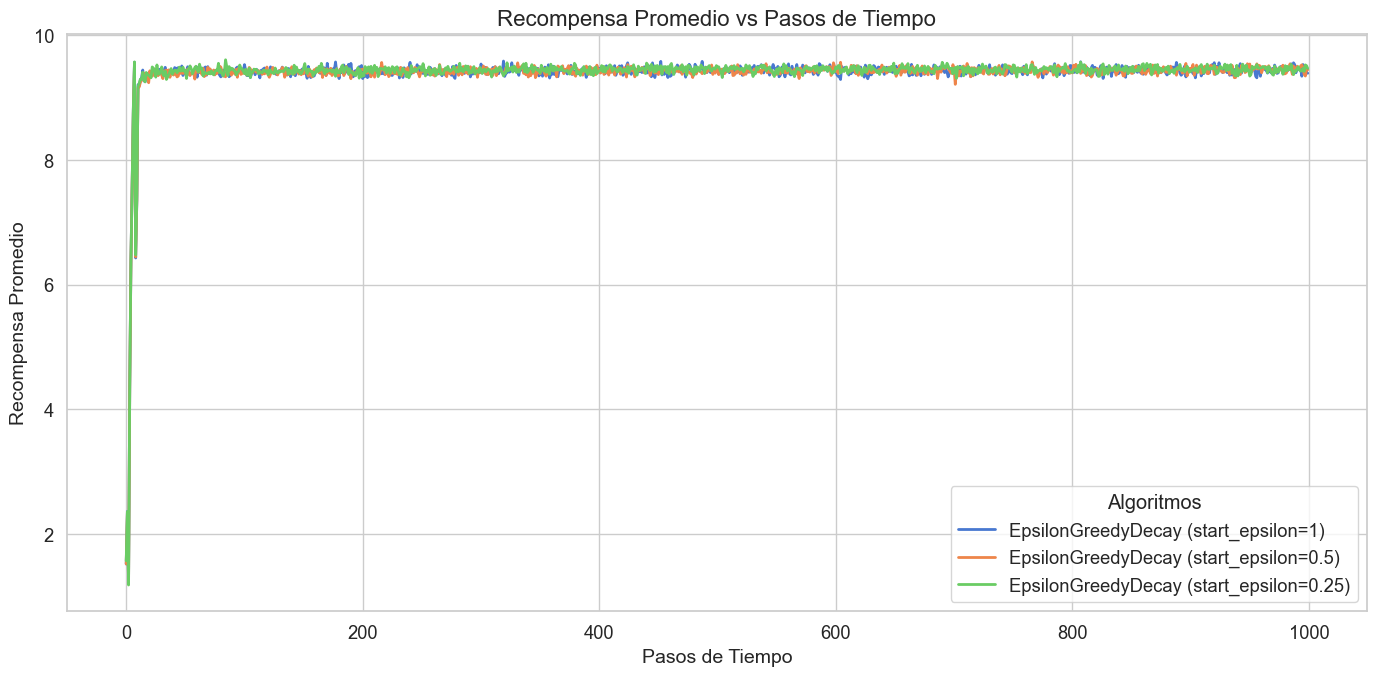

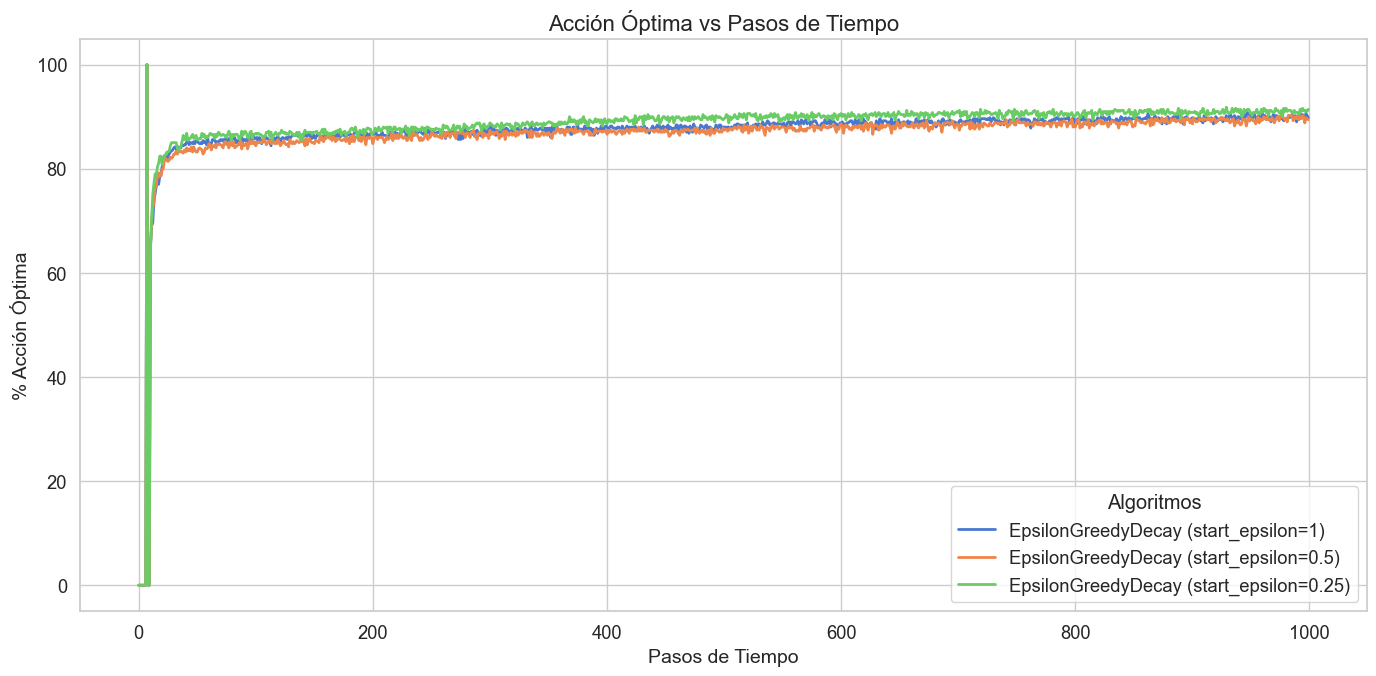

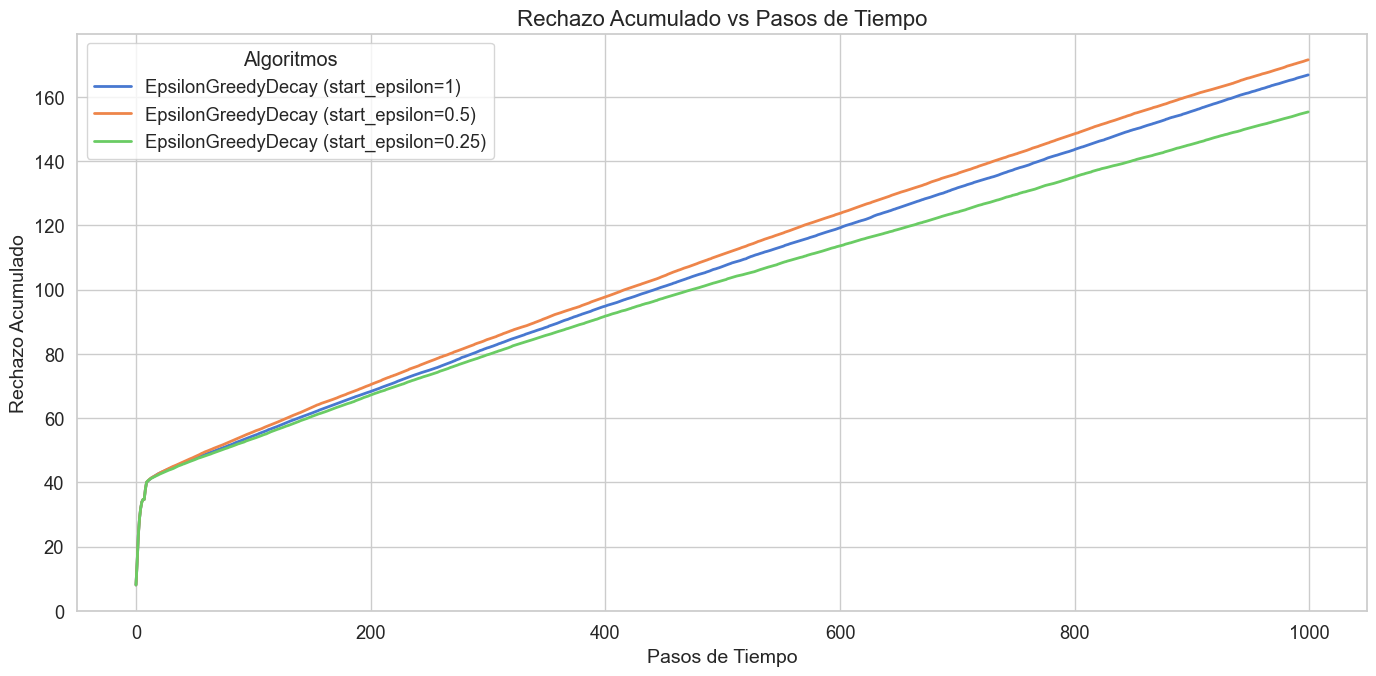

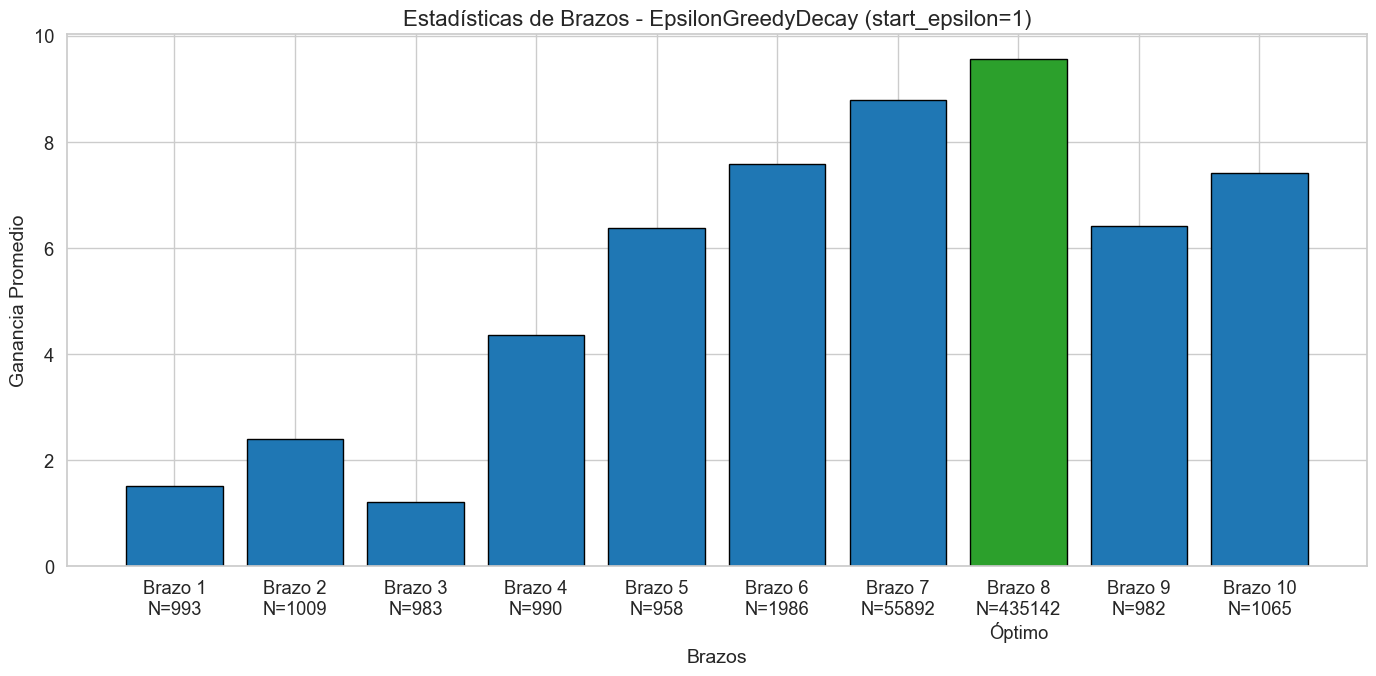

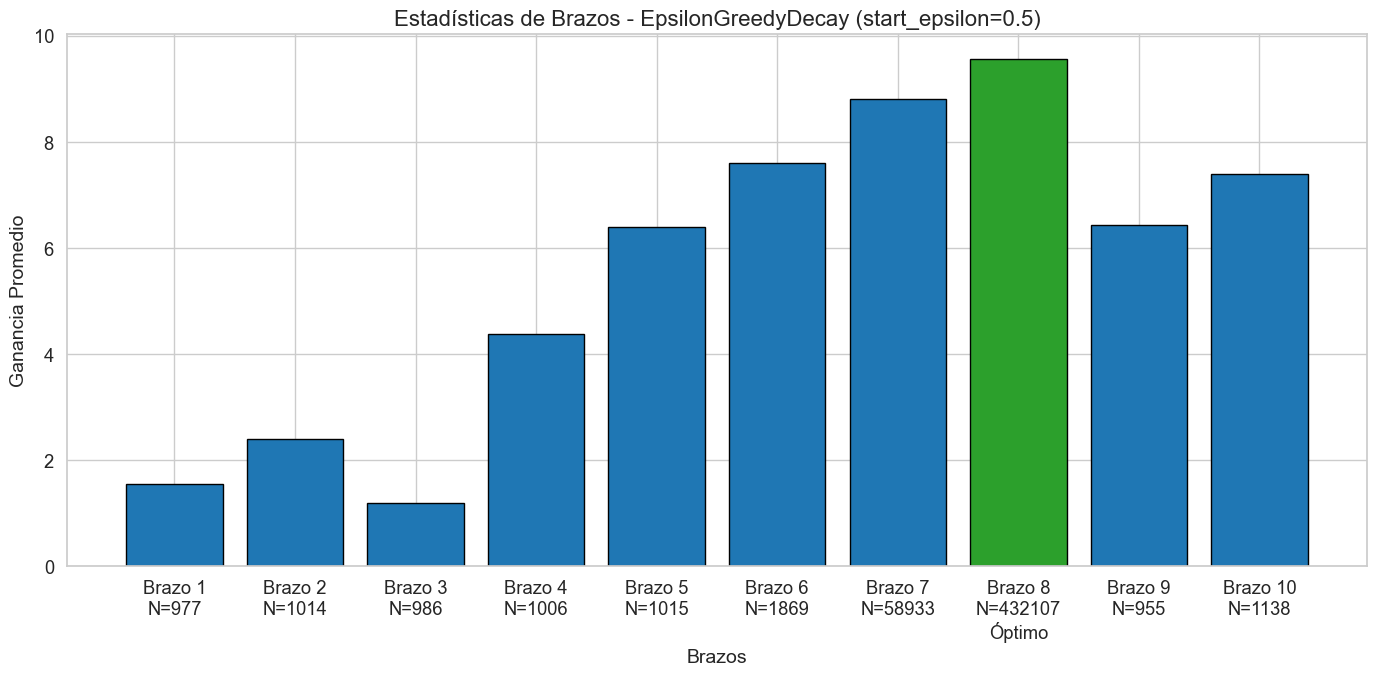

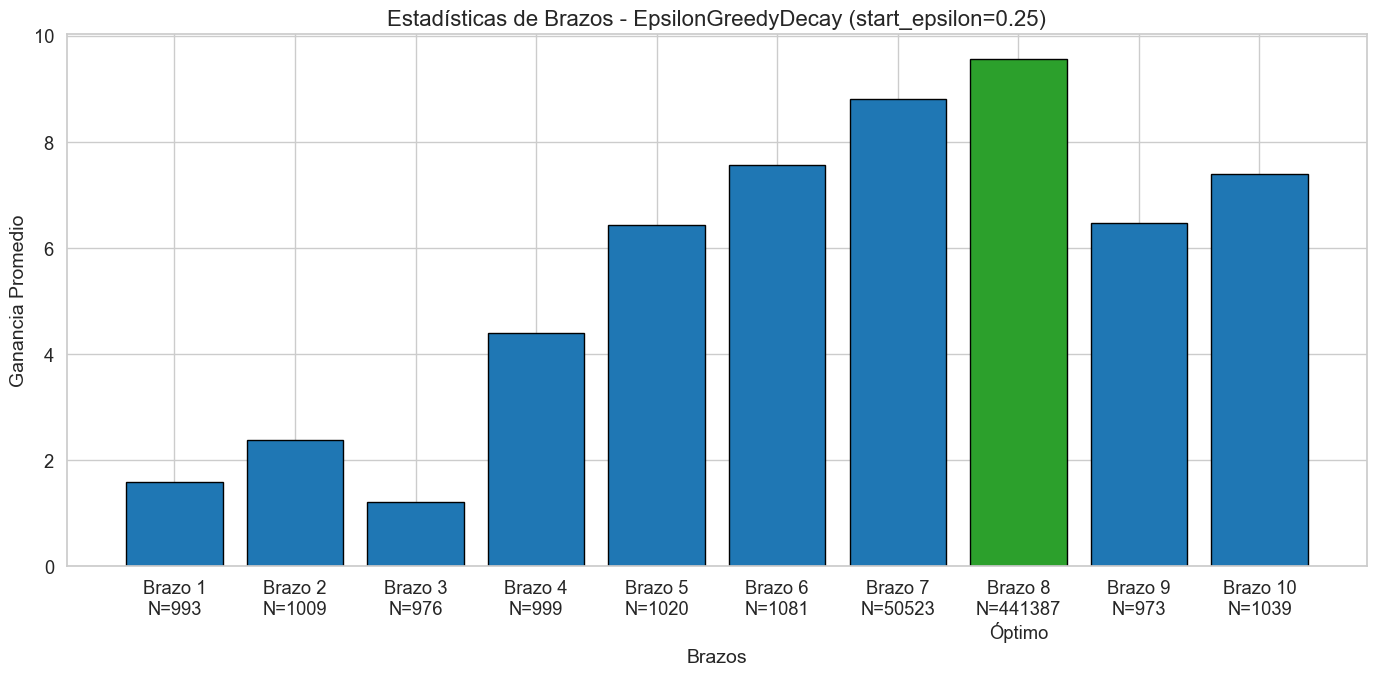

In [5]:
# Creación del bandit
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_normal, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

Se muestran unos gráficos de líneas donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio/acción óptima/rechazo acumulado** por cada algoritmo. 

Además de las gráficas de líneas, se muestra un **histograma de barras** que resume el comportamiento de cada algoritmo respecto a los distintos brazos del bandido. En el eje **x** aparecen los brazos disponibles, mientras que en el eje **y** se representa la **recompensa media observada** para cada uno de ellos. Debajo de cada barra se indica el valor **N**, que corresponde al número de veces que dicho brazo ha sido seleccionado durante todas las ejecuciones del experimento, **N** suma en total ``stepsxruns``. 


En el caso del algoritmo **$\epsilon$-greedy con decaimiento**, las gráficas de líneas reflejan cómo el comportamiento del agente evoluciona a lo largo del tiempo. Al inicio, los tres valores de $\epsilon$ considerados favorecen una exploración intensa, lo que permite probar ampliamente los distintos brazos del bandido. Esto explica la mayor variabilidad inicial en las curvas y el rápido ajuste del algoritmo en las primeras etapas.

A medida que avanza el tiempo, el valor de ε disminuye progresivamente, reduciendo la exploración y favoreciendo la explotación de los brazos que han mostrado mejores resultados. Como consecuencia, las estrategias convergen hacia comportamientos muy similares, con un rendimiento estable y cercano al óptimo, donde las diferencias entre configuraciones se reducen considerablemente.

En este contexto, se observa que **$\epsilon$ = 0.25** obtiene un rendimiento ligeramente superior, ya que introduce una cantidad de exploración suficiente sin resultar excesiva. Esto permite concentrar antes las decisiones en los brazos más prometedores, evitando exploración innecesaria en fases en las que el algoritmo ya dispone de estimaciones relativamente fiables.

---

## Ejecución del experimento Binomial

Bandit with 10 arms: ArmBinomial(n=10, p=0.4), ArmBinomial(n=10, p=0.86), ArmBinomial(n=10, p=0.22), ArmBinomial(n=10, p=0.69), ArmBinomial(n=10, p=0.58), ArmBinomial(n=10, p=0.15), ArmBinomial(n=10, p=0.79), ArmBinomial(n=10, p=0.67), ArmBinomial(n=10, p=0.12), ArmBinomial(n=10, p=0.88)
Optimal arm: 10 with expected reward=8.8


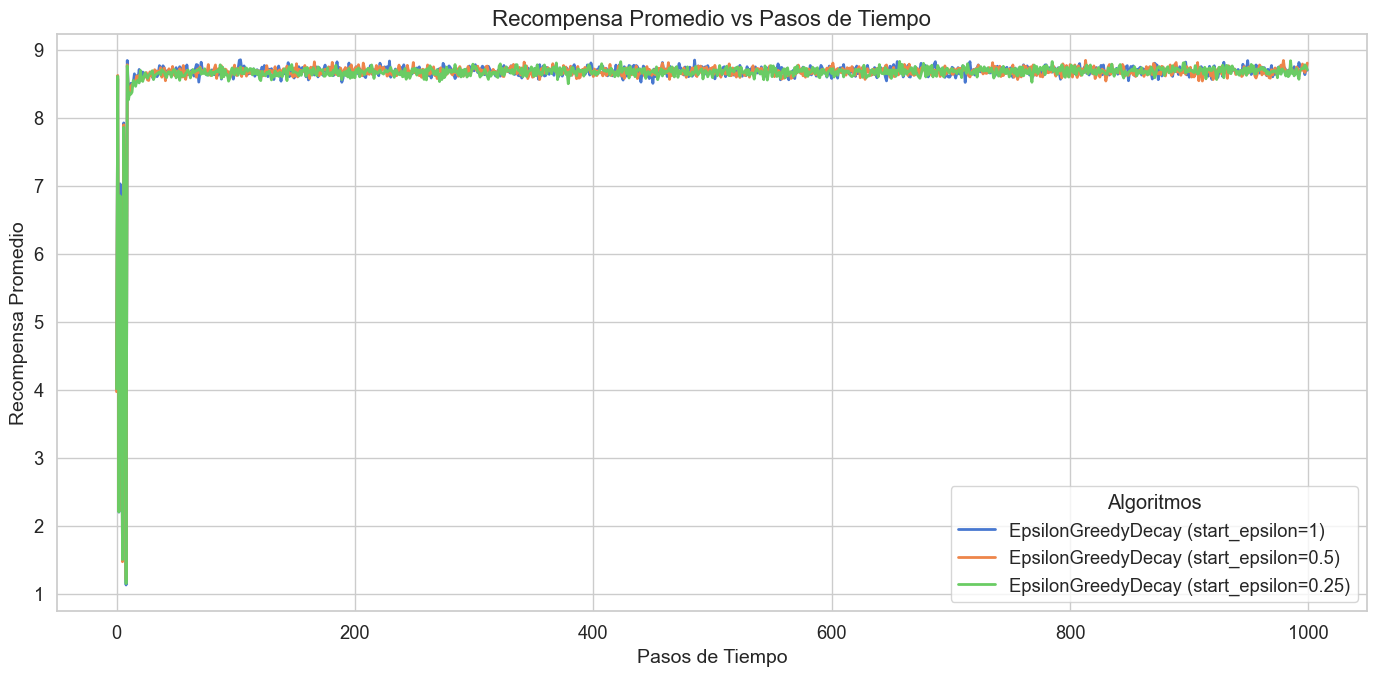

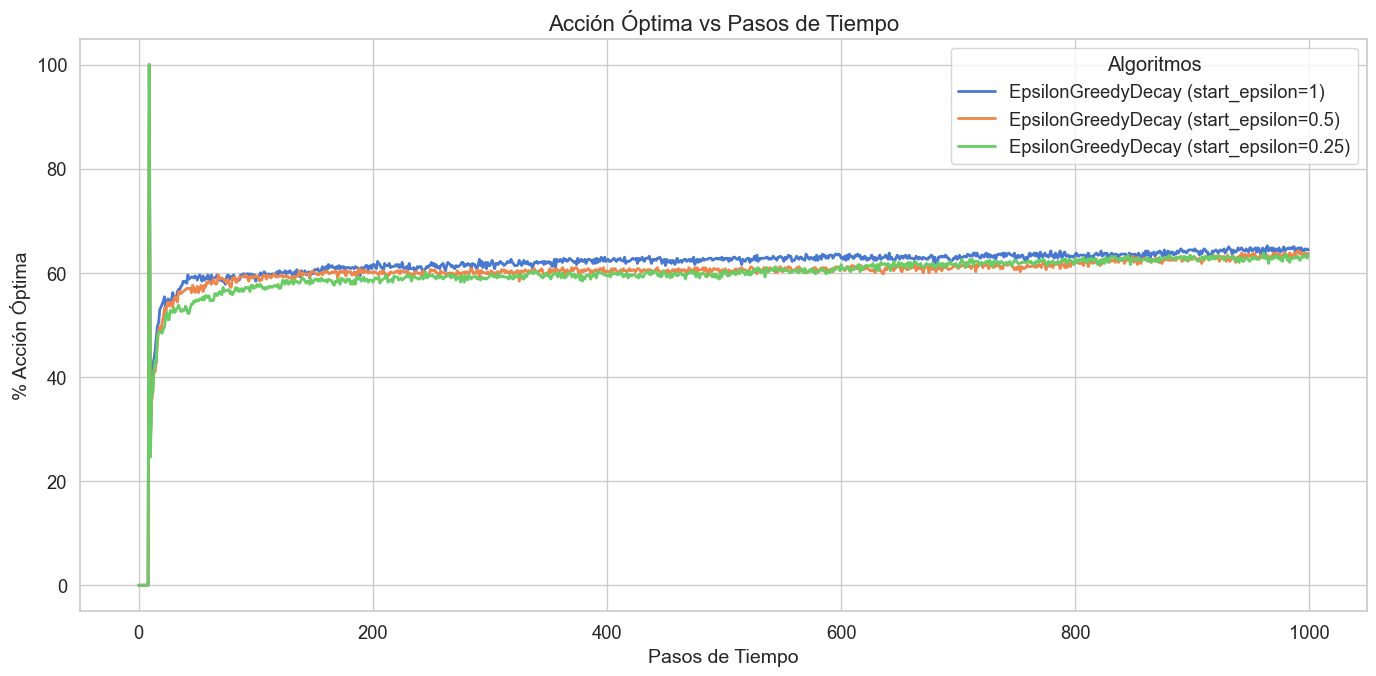

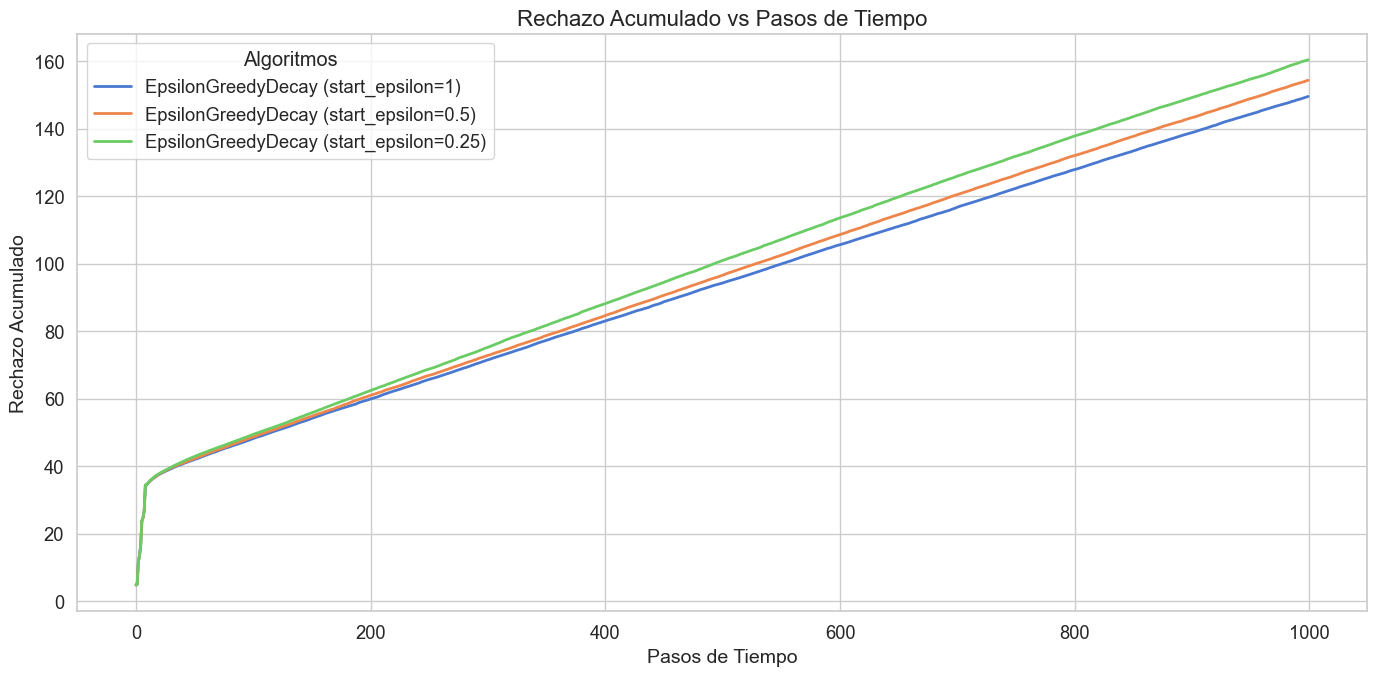

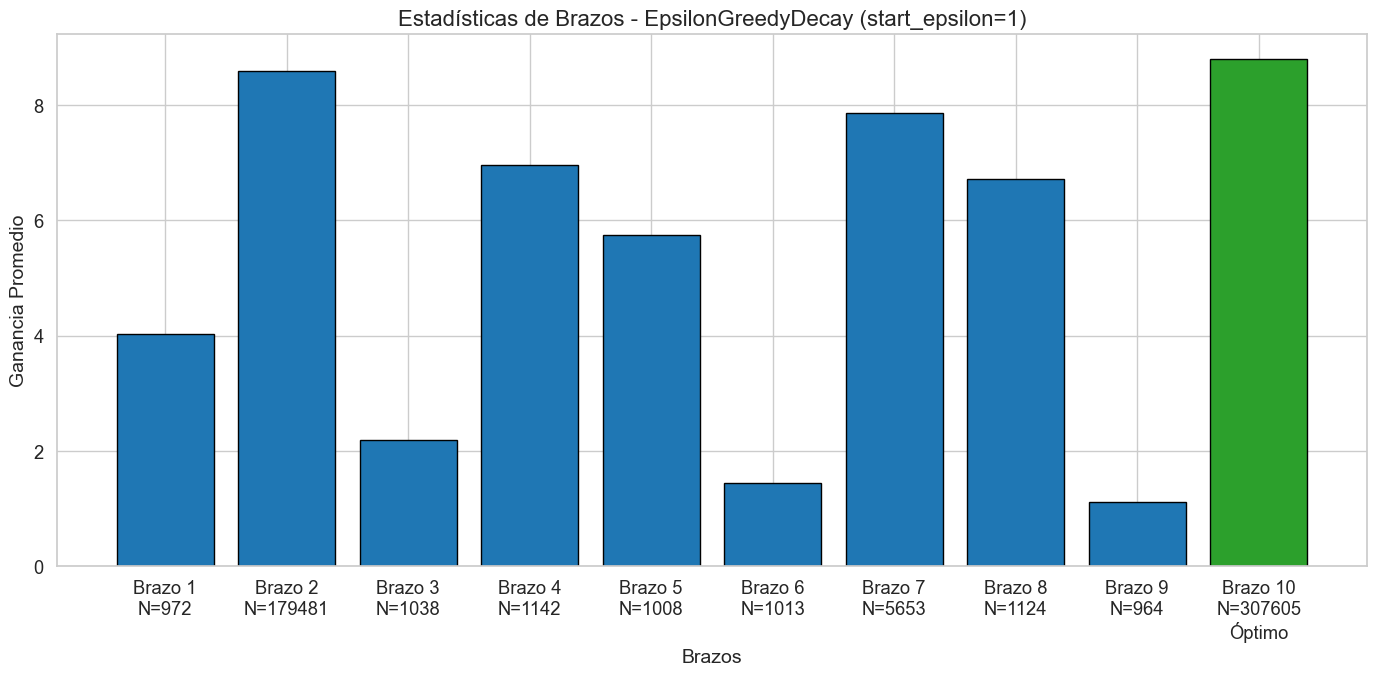

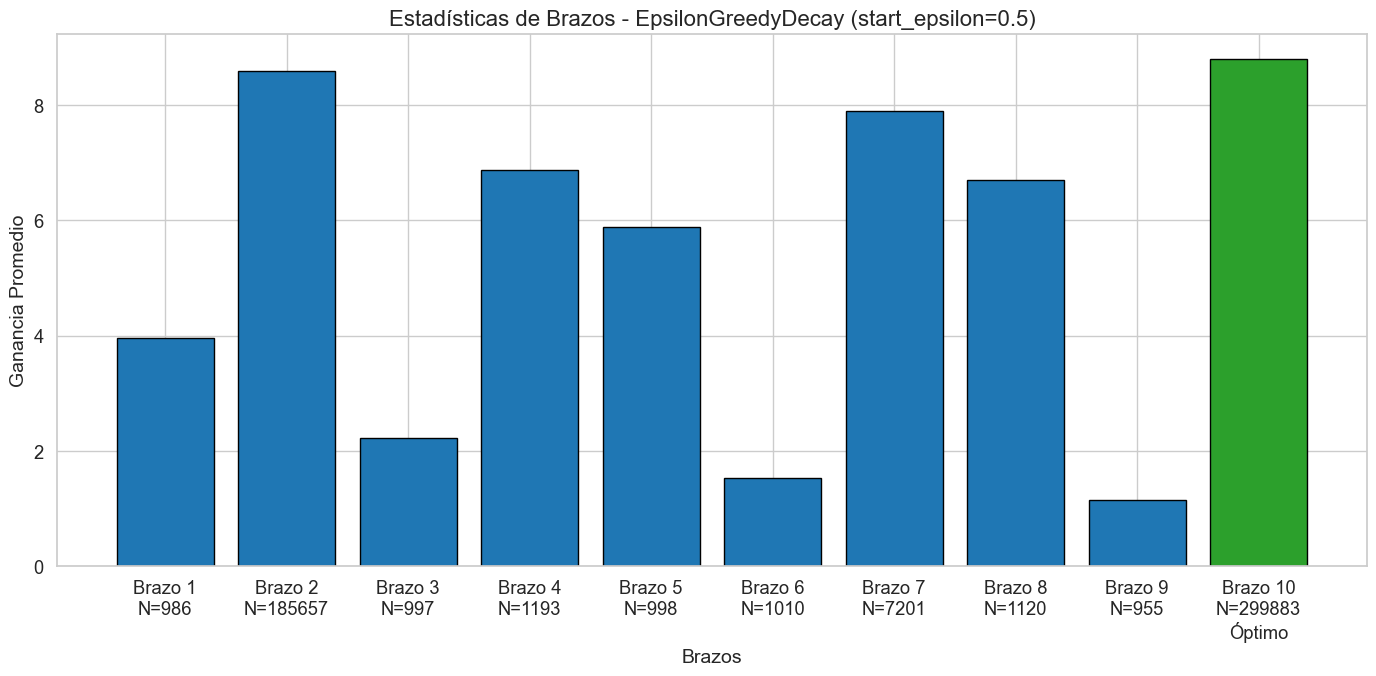

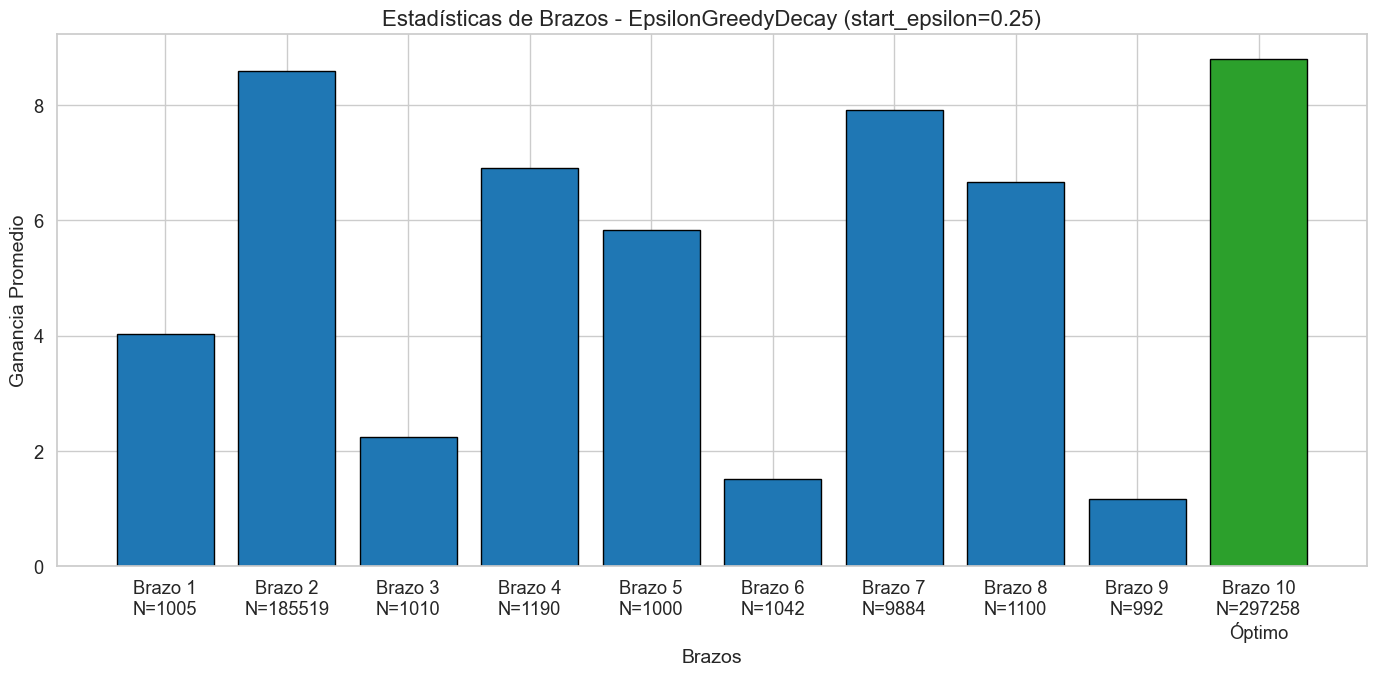

In [6]:
# Se fija la semilla de nuevo inicio de cada experimento para garantizar la reproducibilidad de cada ejecución completa
# El objetivo es poder comparar distintas técnica (UCB1, softmax...) ya que cada técnica genera un número de veces diferente números aleatorios
np.random.seed(42)

# Creación del bandit
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_binomial)

optimal_arm = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_binomial, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

En el caso de repetir el experimento con una distribución de Binomial, se observa que el rendimiento global de las distintas estrategias es bastante similar entre sí. Sin embargo, el porcentaje de selección de la acción óptima disminuye ligeramente. Este comportamiento es coherente con la configuración del problema, ya que existen varios brazos con probabilidades de recompensa muy cercanas al óptimo. Esto hace que sea más difícil distinguir de forma consistente el mejor brazo.

Como consecuencia, aunque el algoritmo logra un rendimiento global similar, la frecuencia con la que se selecciona exactamente la acción óptima es menor.

## Ejecución del experimento Bernoulli

Bandit with 10 arms: ArmBinomial(n=1, p=0.4), ArmBinomial(n=1, p=0.86), ArmBinomial(n=1, p=0.22), ArmBinomial(n=1, p=0.69), ArmBinomial(n=1, p=0.58), ArmBinomial(n=1, p=0.15), ArmBinomial(n=1, p=0.79), ArmBinomial(n=1, p=0.67), ArmBinomial(n=1, p=0.12), ArmBinomial(n=1, p=0.88)
Optimal arm: 10 with expected reward=0.88


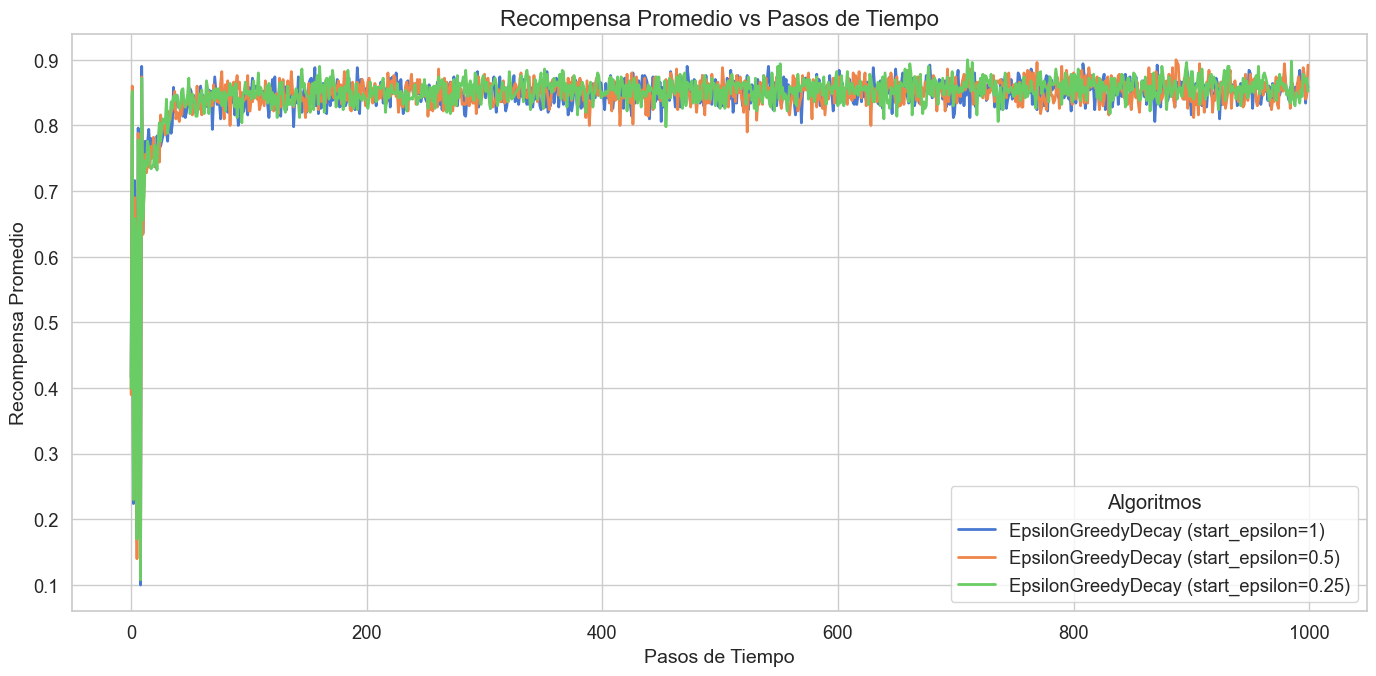

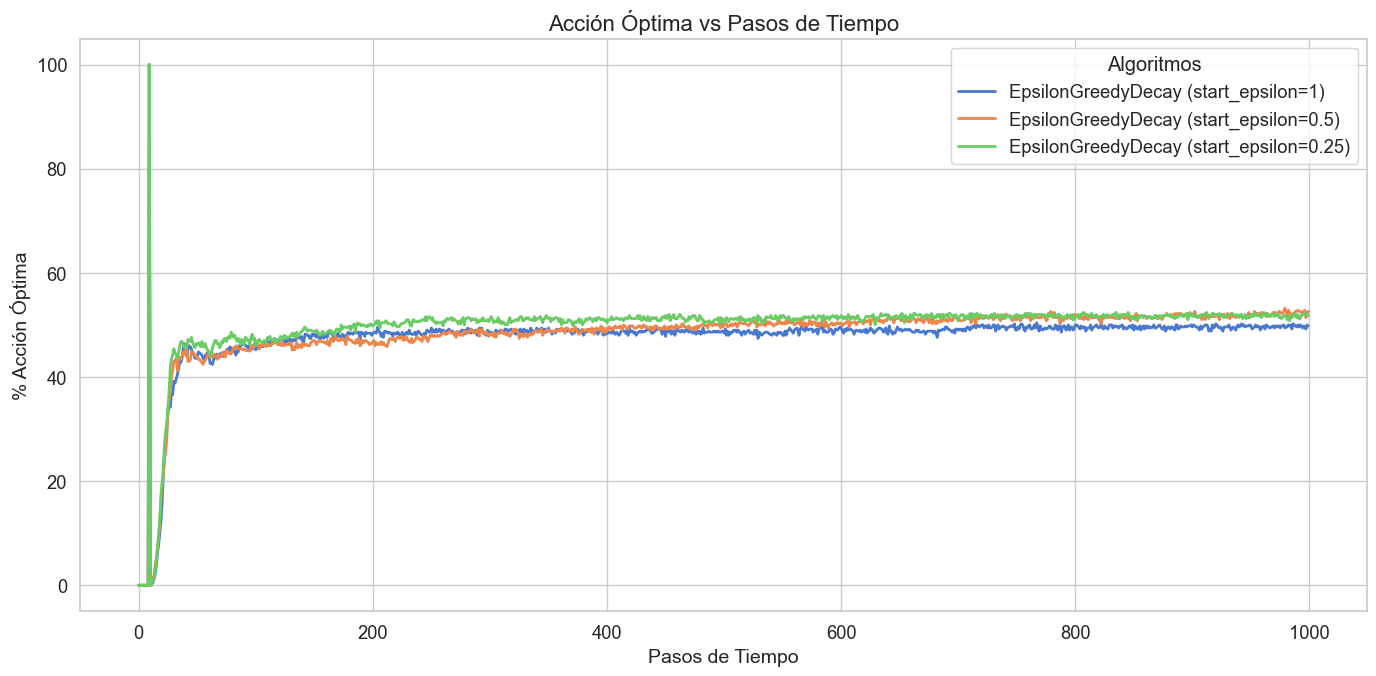

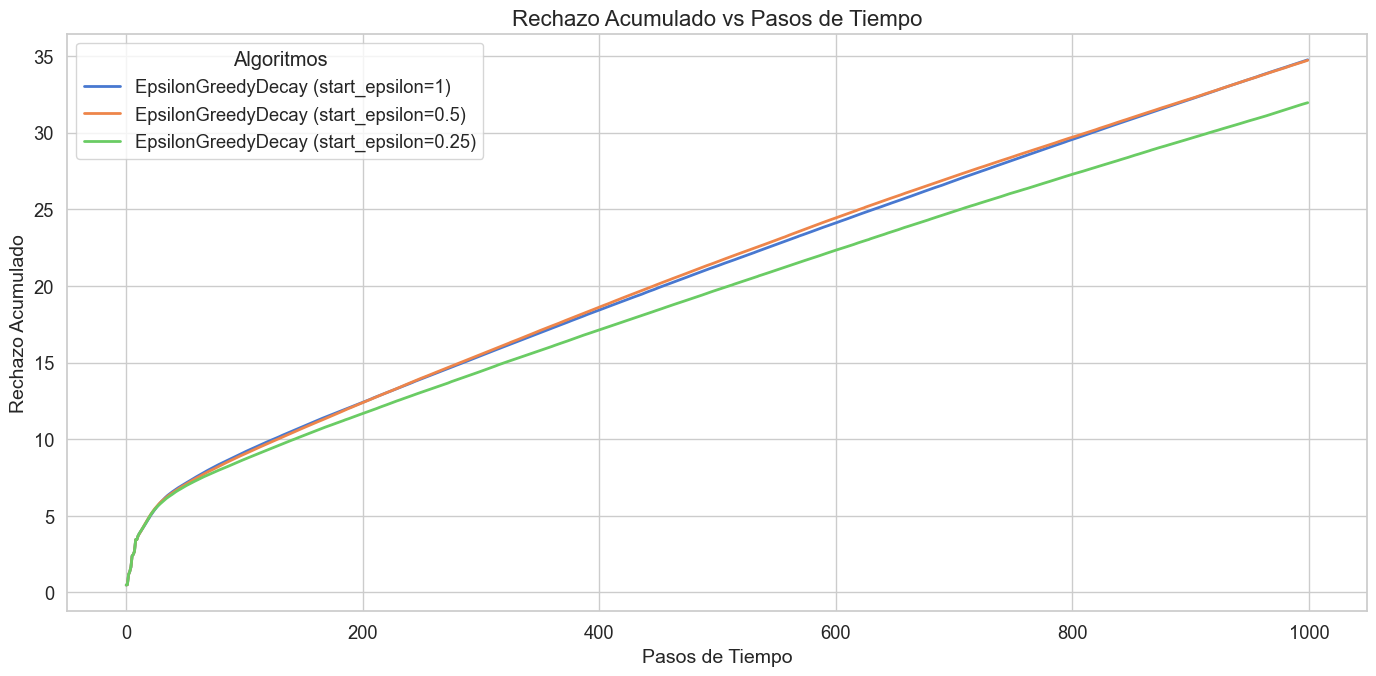

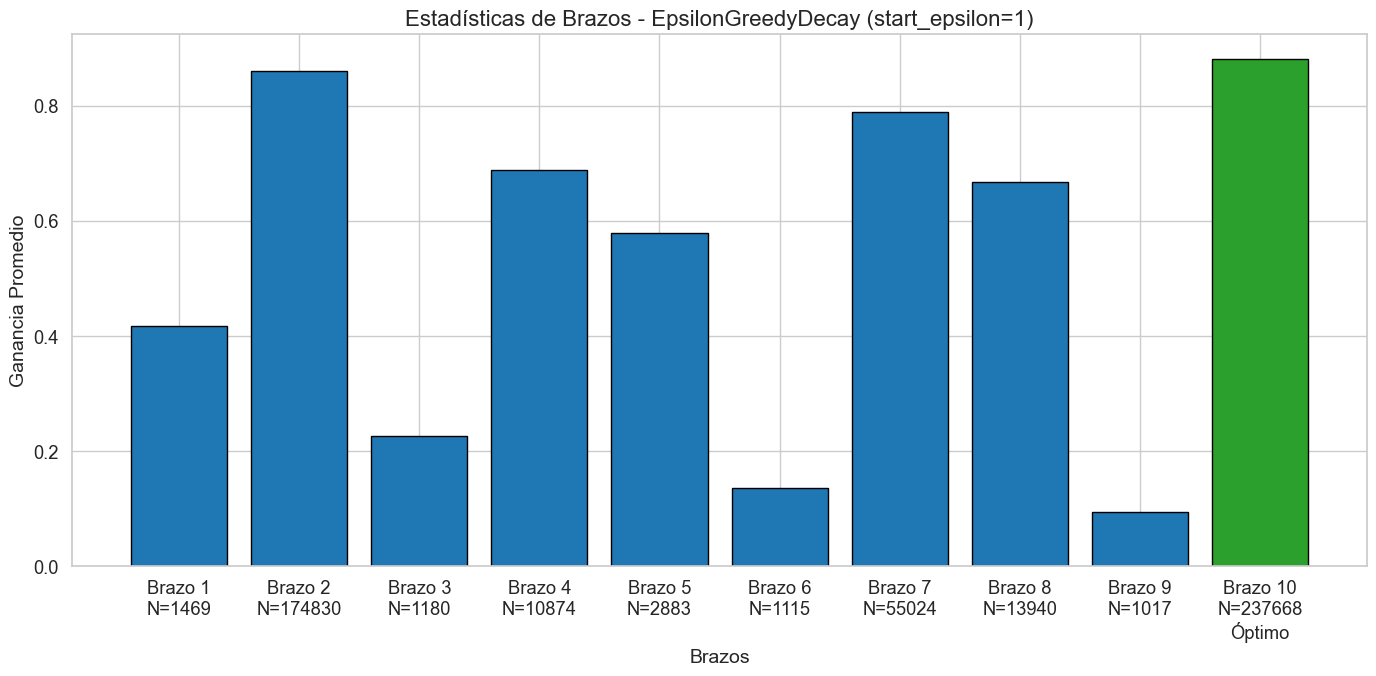

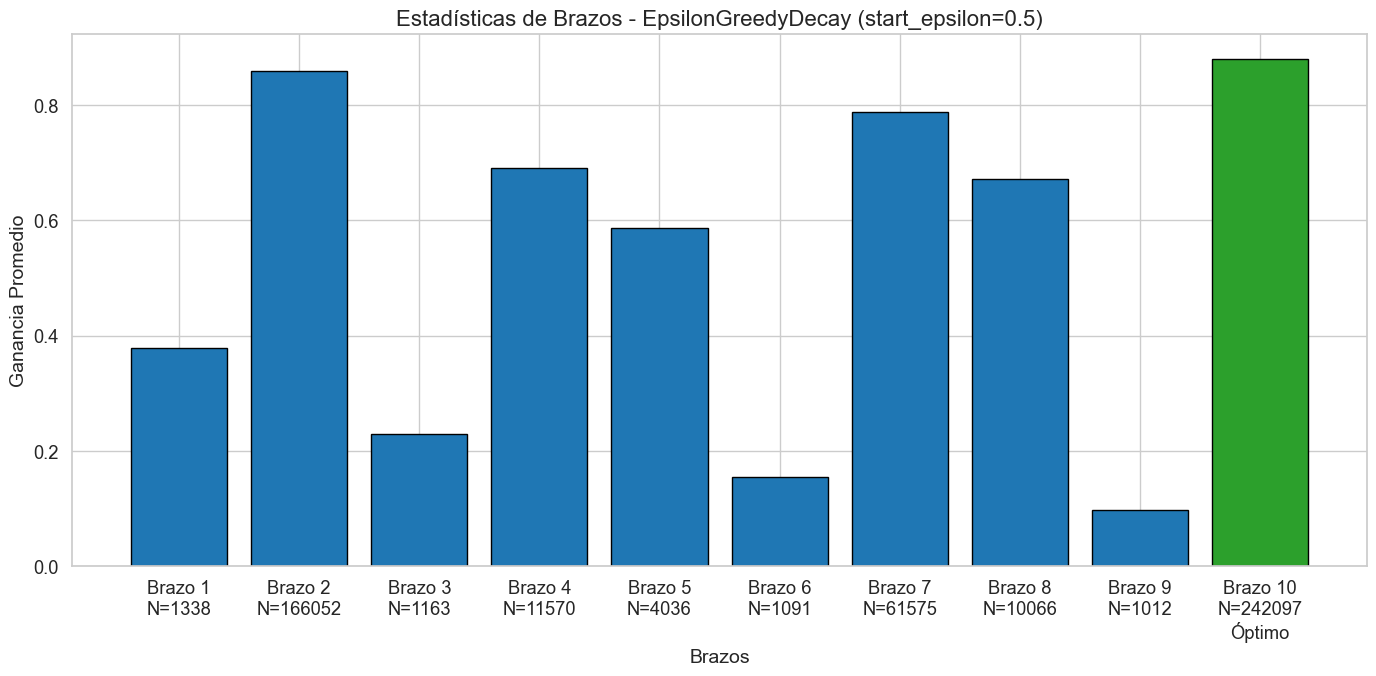

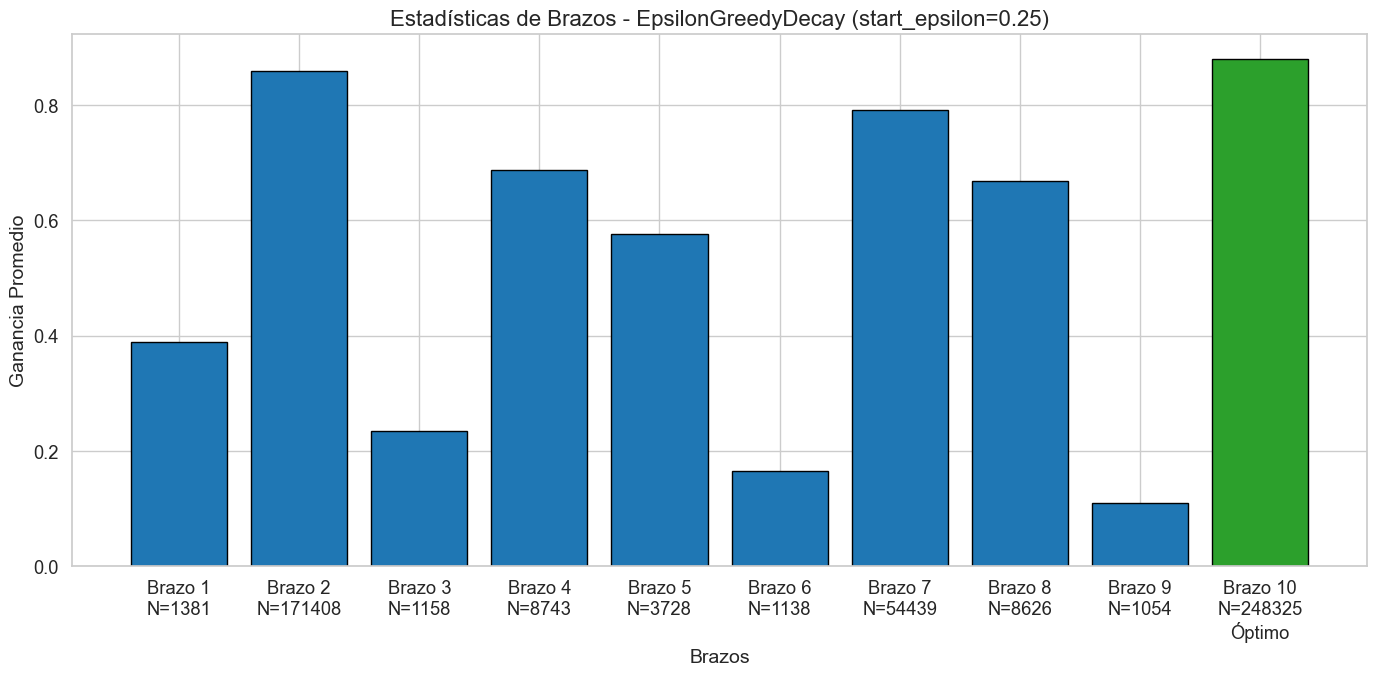

In [7]:
# Se fija la semilla de nuevo inicio de cada experimento para garantizar la reproducibilidad de cada ejecución completa
# El objetivo es poder comparar distintas técnica (UCB1, softmax...) ya que cada técnica genera un número de veces diferente números aleatorios
np.random.seed(42)

# Creación del bandit
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_bernoulli)

optimal_arm = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_bernoulli, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

En el caso de repetir el experimento con una distribución de Bernoulli, se observa que el rendimiento global de las distintas estrategias es bastante similar entre sí. Sin embargo, como ocurría en la distribución Binomial, el porcentaje de selección de la acción óptima disminuye. 

---

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado solo en el estudio del algoritmo epsilon-greedy con decaimiento, llegando a las siguientes conclusiones:


- Cuando el valor inicial de **$\epsilon$  es alto (1)**, el algoritmo realiza una exploración muy intensa al principio, lo que permite obtener información rápida sobre todos los brazos. Sin embargo, esta exploración excesiva introduce mucho error en fases iniciales.

- Para valores intermedios iniciales como **$\epsilon$  = 0.5**, se observa un equilibrio razonable entre exploración y explotación, aunque no siempre es el comportamiento más eficiente en este entorno concreto.

- Un valor inicial más bajo como **$\epsilon$  = 0.25** tiende a ofrecer el mejor rendimiento global, ya que proporciona la exploración suficiente para identificar los brazos óptimos sin prolongar innecesariamente la fase exploratoria.

- En general, el rendimiento medio es robusto frente a cambios en la distribución de recompensas (normal, binomial o Bernoulli), especialmente gracias al mecanismo de decaimiento, que reduce progresivamente la exploración y estabiliza el aprendizaje.

En conclusión, **el uso de ε-greedy con decaimiento permite un comportamiento adaptativo en el que una exploración inicial controlada mejora el rendimiento, siendo especialmente efectivo cuando el nivel inicial de exploración no es excesivo**.